In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
from tqdm import tqdm

from Greedy_SOSP import Greedy_SOSP

DATA_PATH = Path("data") / "roadNet-PA.txt"
RESULTS_GSOSP_CSV = Path("roadNet-PA_results_GSOSP.csv")

In [2]:
def load_roadnet_edges(path):
    """Read the RoadNet-CA directed edge list from the dataset file."""
    return pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["source", "target"],
        dtype={"source": int, "target": int},
    )


def build_subgraph(edge_df):
    """Build a directed graph from an edge DataFrame."""
    G = nx.DiGraph()
    G.add_edges_from(edge_df.itertuples(index=False, name=None))
    return G


edge_df = load_roadnet_edges(DATA_PATH)
print(f"Loaded {len(edge_df):,} edges from {DATA_PATH}")

Loaded 3,083,796 edges from data\roadNet-PA.txt


In [7]:
EDGE_COUNTS = [50_000, 100_000, 200_000, 400_000, 800_000, 1_600_000, 2_500_500,len(edge_df)]
REPEAT = 5

results = []

total_runs = len(EDGE_COUNTS) * REPEAT
with tqdm(total=total_runs, desc="RoadNet-CA experiments") as pbar:
    for edges_count in EDGE_COUNTS:
        subset = edge_df.iloc[:edges_count]
        for trial in range(REPEAT):
            G = build_subgraph(subset)
            start = time.perf_counter()
            Greedy_SOSP(G)
            end = time.perf_counter()

            results.append({
                "edges": edges_count,
                "nodes": G.number_of_nodes(),
                "runtime": end - start,
                "trial": trial + 1,
            })
            pbar.update(1)


results_df = pd.DataFrame(results)
results_df.head()

RoadNet-CA experiments: 100%|██████████| 40/40 [02:29<00:00,  3.74s/it]


,edges,nodes,runtime,trial
0,50000,18699,0.028079,1
1,50000,18699,0.022620,2
2,50000,18699,0.022122,3
3,50000,18699,0.021848,4
4,50000,18699,0.021785,5


In [8]:
results_df.to_csv(RESULTS_GSOSP_CSV, index=False)
print(f"Saved runtime results to {RESULTS_GSOSP_CSV}")

Saved runtime results to roadNet-PA_results_GSOSP.csv


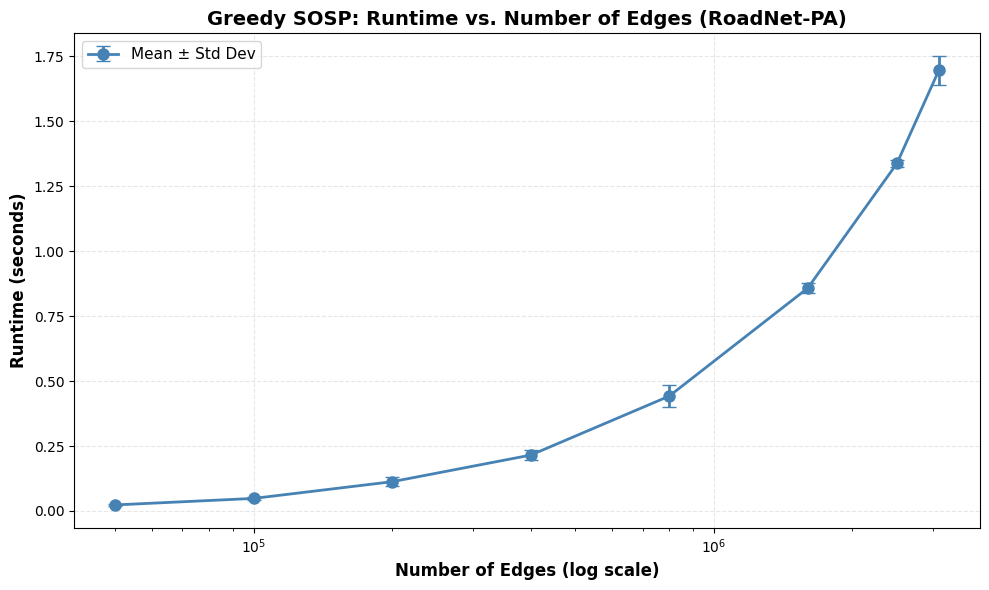


Runtime Statistics by Edges:
  edges     mean      std
  50000 0.023291 0.002697
 100000 0.048403 0.004590
 200000 0.112770 0.017536
 400000 0.215152 0.020768
 800000 0.442251 0.041769
1600000 0.857961 0.019772
2500500 1.338105 0.013340
3083796 1.696390 0.056008


In [9]:
# Load and plot runtime results for Greedy_SOSP
gsosp_results = pd.read_csv(RESULTS_GSOSP_CSV)

# Aggregate runtimes by edges (mean and std)
runtime_by_edges = gsosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot mean runtime with error bars
ax.errorbar(runtime_by_edges['edges'], runtime_by_edges['mean'], 
            yerr=runtime_by_edges['std'], marker='o', linewidth=2, 
            markersize=8, capsize=5, label='Mean ± Std Dev', color='steelblue')

# Formatting
ax.set_xlabel('Number of Edges', fontsize=12, fontweight='bold')
ax.set_ylabel('Runtime (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Greedy SOSP: Runtime vs. Number of Edges (RoadNet-PA)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

# Use log scale for x-axis if there's a large range
if runtime_by_edges['edges'].max() / runtime_by_edges['edges'].min() > 50:
    ax.set_xscale('log')
    ax.set_xlabel('Number of Edges (log scale)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRuntime Statistics by Edges:")
print(runtime_by_edges.to_string(index=False))

In [2]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from Robust_MOSP import  Robust_MOSP

DATA_PATH = Path("data") / "roadNet-PA.txt"
RESULTS_RMOSP_CSV = Path("roadNet-PA_results_RMOSP.csv")

In [11]:
def load_roadnet_edges(path):
    """Read the RoadNet-CA directed edge list from the dataset file."""
    return pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["source", "target"],
        dtype={"source": int, "target": int},
    )


def build_subgraph(edge_df):
    """Build a directed graph from an edge DataFrame."""
    G = nx.DiGraph()
    G.add_edges_from(edge_df.itertuples(index=False, name=None))
    return G


edge_df = load_roadnet_edges(DATA_PATH)
print(f"Loaded {len(edge_df):,} edges from {DATA_PATH}")

Loaded 3,083,796 edges from data\roadNet-PA.txt


In [12]:
EDGE_COUNTS = [50_000, 100_000, 200_000, 400_000, 800_000, 1_600_000, 2_500_500,len(edge_df)]
REPEAT = 5

results = []

total_runs = len(EDGE_COUNTS) * REPEAT
with tqdm(total=total_runs, desc="RoadNet-CA experiments") as pbar:
    for edges_count in EDGE_COUNTS:
        subset = edge_df.iloc[:edges_count]
        for trial in range(REPEAT):
            G = build_subgraph(subset)
            start = time.perf_counter()
            Robust_MOSP(G)
            end = time.perf_counter()

            results.append({
                "edges": edges_count,
                "nodes": G.number_of_nodes(),
                "runtime": end - start,
                "trial": trial + 1,
            })
            pbar.update(1)


results_df = pd.DataFrame(results)
results_df.head()

RoadNet-CA experiments: 100%|██████████| 40/40 [1:14:38<00:00, 111.97s/it]


,edges,nodes,runtime,trial
0,50000,18699,4.739185,1
1,50000,18699,4.436299,2
2,50000,18699,10.089409,3
3,50000,18699,4.975624,4
4,50000,18699,4.914477,5


In [13]:
results_df.to_csv(RESULTS_RMOSP_CSV, index=False)
print(f"Saved runtime results to {RESULTS_RMOSP_CSV}")

Saved runtime results to roadNet-PA_results_RMOSP.csv


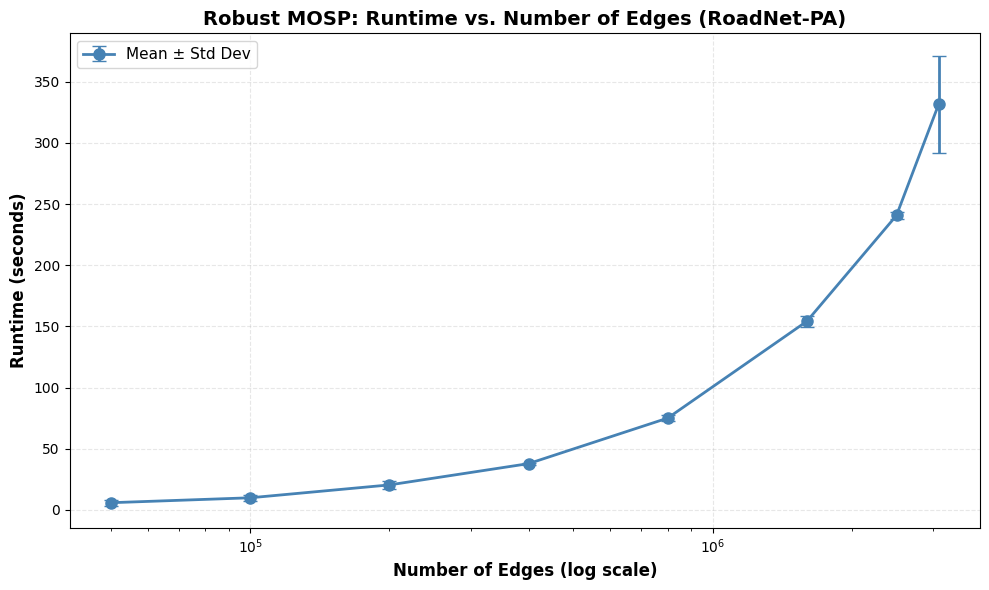


Runtime Statistics by Edges:
  edges       mean       std
  50000   5.830999  2.389716
 100000   9.859407  2.478790
 200000  20.374590  3.546290
 400000  37.770326  0.804363
 800000  75.005054  2.313031
1600000 154.154904  4.369034
2500500 240.724278  2.786228
3083796 331.476405 39.665030


In [3]:
# Load and plot runtime results for Greedy_SOSP
gsosp_results = pd.read_csv(RESULTS_RMOSP_CSV)

# Aggregate runtimes by edges (mean and std)
runtime_by_edges = gsosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot mean runtime with error bars
ax.errorbar(runtime_by_edges['edges'], runtime_by_edges['mean'], 
            yerr=runtime_by_edges['std'], marker='o', linewidth=2, 
            markersize=8, capsize=5, label='Mean ± Std Dev', color='steelblue')

# Formatting
ax.set_xlabel('Number of Edges', fontsize=12, fontweight='bold')
ax.set_ylabel('Runtime (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Robust MOSP: Runtime vs. Number of Edges (RoadNet-PA)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

# Use log scale for x-axis if there's a large range
if runtime_by_edges['edges'].max() / runtime_by_edges['edges'].min() > 50:
    ax.set_xscale('log')
    ax.set_xlabel('Number of Edges (log scale)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRuntime Statistics by Edges:")
print(runtime_by_edges.to_string(index=False))

**combined greedy sosp and robust mosp**

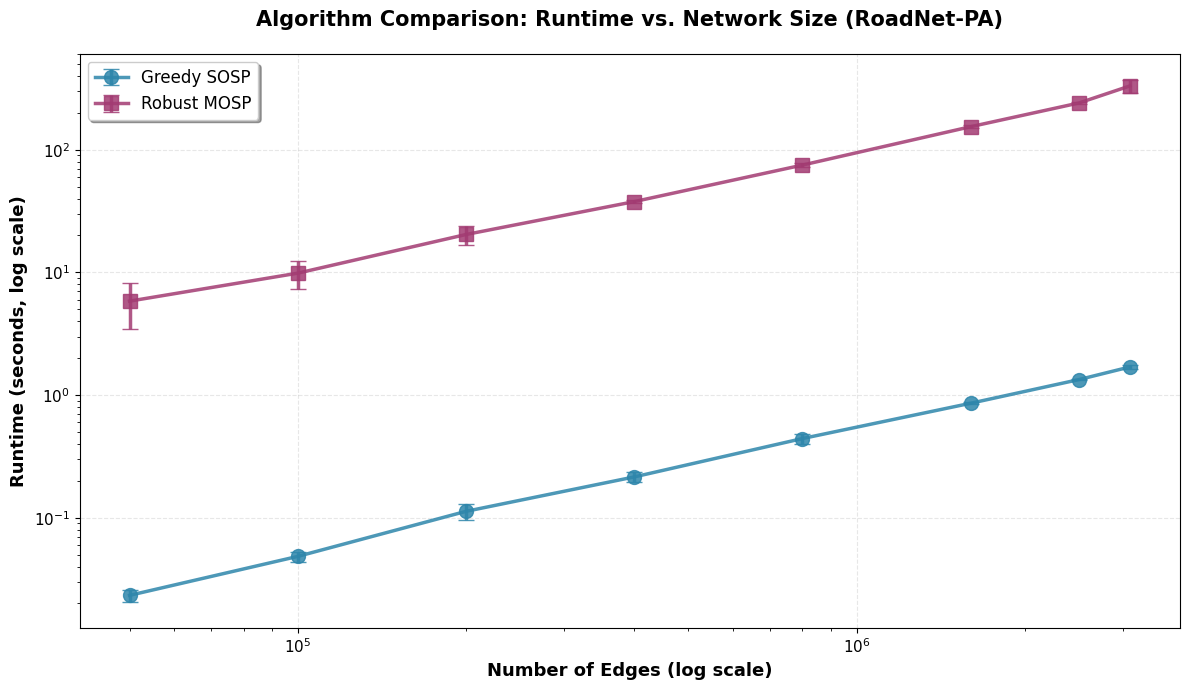

COMBINED ALGORITHM COMPARISON - RoadNet-PA

Greedy SOSP Runtime Statistics:
  edges     mean      std
  50000 0.023291 0.002697
 100000 0.048403 0.004590
 200000 0.112770 0.017536
 400000 0.215152 0.020768
 800000 0.442251 0.041769
1600000 0.857961 0.019772
2500500 1.338105 0.013340
3083796 1.696390 0.056008

Robust MOSP Runtime Statistics:
  edges       mean       std
  50000   5.830999  2.389716
 100000   9.859407  2.478790
 200000  20.374590  3.546290
 400000  37.770326  0.804363
 800000  75.005054  2.313031
1600000 154.154904  4.369034
2500500 240.724278  2.786228
3083796 331.476405 39.665030

SPEEDUP ANALYSIS (Robust MOSP / Greedy SOSP):
Edges:  50000 | Speedup:   250.36x
Edges: 100000 | Speedup:   203.69x
Edges: 200000 | Speedup:   180.67x
Edges: 400000 | Speedup:   175.55x
Edges: 800000 | Speedup:   169.60x
Edges: 1600000 | Speedup:   179.68x
Edges: 2500500 | Speedup:   179.90x
Edges: 3083796 | Speedup:   195.40x


In [2]:
# Combined plot: Greedy SOSP vs Robust MOSP on RoadNet-CA
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Define paths
RESULTS_GSOSP_CSV = Path("roadNet-PA_results_GSOSP.csv")
RESULTS_RMOSP_CSV = Path("roadNet-PA_results_RMOSP.csv")

# Load results from both algorithms
gsosp_results = pd.read_csv(RESULTS_GSOSP_CSV)
rmosp_results = pd.read_csv(RESULTS_RMOSP_CSV)

# Aggregate runtimes by edges (mean and std)
gsosp_runtime = gsosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()
gsosp_runtime['algorithm'] = 'Greedy SOSP'

rmosp_runtime = rmosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()
rmosp_runtime['algorithm'] = 'Robust MOSP'

# Create the combined plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot Greedy SOSP
ax.errorbar(gsosp_runtime['edges'], gsosp_runtime['mean'], 
            yerr=gsosp_runtime['std'], marker='o', linewidth=2.5, 
            markersize=10, capsize=6, label='Greedy SOSP', 
            color='#2E86AB', alpha=0.85)

# Plot Robust MOSP
ax.errorbar(rmosp_runtime['edges'], rmosp_runtime['mean'], 
            yerr=rmosp_runtime['std'], marker='s', linewidth=2.5, 
            markersize=10, capsize=6, label='Robust MOSP', 
            color='#A23B72', alpha=0.85)

# Formatting for research paper
ax.set_xlabel('Number of Edges', fontsize=13, fontweight='bold')
ax.set_ylabel('Runtime (seconds)', fontsize=13, fontweight='bold')
ax.set_title('Algorithm Comparison: Runtime vs. Network Size (RoadNet-PA)', 
             fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(fontsize=12, loc='upper left', frameon=True, shadow=True)

# Use log scale for x-axis for better visualization
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of Edges (log scale)', fontsize=13, fontweight='bold')
ax.set_ylabel('Runtime (seconds, log scale)', fontsize=13, fontweight='bold')

# Add tick formatting
ax.tick_params(axis='both', which='major', labelsize=11)

plt.tight_layout()
# plt.savefig('roadNet-CA_combined_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print comparison statistics
print("=" * 70)
print("COMBINED ALGORITHM COMPARISON - RoadNet-PA")
print("=" * 70)
print("\nGreedy SOSP Runtime Statistics:")
print(gsosp_runtime[['edges', 'mean', 'std']].to_string(index=False))
print("\nRobust MOSP Runtime Statistics:")
print(rmosp_runtime[['edges', 'mean', 'std']].to_string(index=False))

# Calculate speedup
print("\n" + "=" * 70)
print("SPEEDUP ANALYSIS (Robust MOSP / Greedy SOSP):")
print("=" * 70)
for edges in gsosp_runtime['edges']:
    gsosp_mean = gsosp_runtime[gsosp_runtime['edges'] == edges]['mean'].values[0]
    rmosp_mean = rmosp_runtime[rmosp_runtime['edges'] == edges]['mean'].values[0]
    speedup = rmosp_mean / gsosp_mean
    print(f"Edges: {edges:>6} | Speedup: {speedup:>8.2f}x")

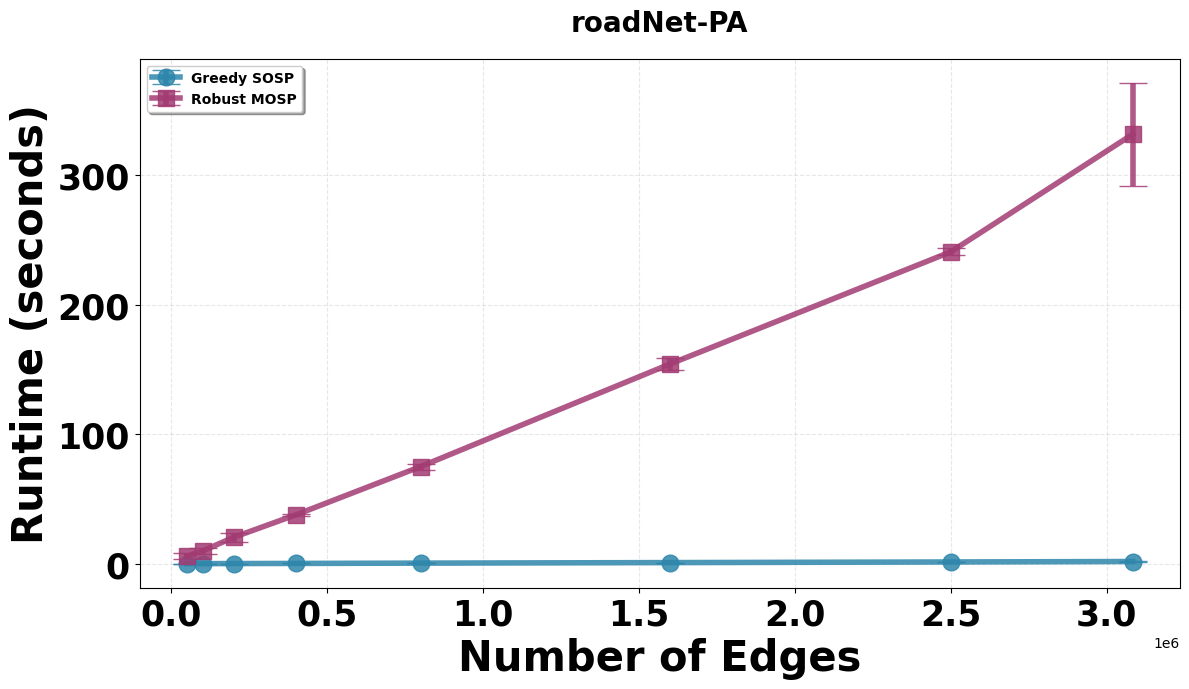

COMBINED ALGORITHM COMPARISON - RoadNet-PA

Greedy SOSP Runtime Statistics:
  edges     mean      std
  50000 0.023291 0.002697
 100000 0.048403 0.004590
 200000 0.112770 0.017536
 400000 0.215152 0.020768
 800000 0.442251 0.041769
1600000 0.857961 0.019772
2500500 1.338105 0.013340
3083796 1.696390 0.056008

Robust MOSP Runtime Statistics:
  edges       mean       std
  50000   5.830999  2.389716
 100000   9.859407  2.478790
 200000  20.374590  3.546290
 400000  37.770326  0.804363
 800000  75.005054  2.313031
1600000 154.154904  4.369034
2500500 240.724278  2.786228
3083796 331.476405 39.665030

SPEEDUP ANALYSIS (Robust MOSP / Greedy SOSP):
Edges:  50000 | Speedup:   250.36x
Edges: 100000 | Speedup:   203.69x
Edges: 200000 | Speedup:   180.67x
Edges: 400000 | Speedup:   175.55x
Edges: 800000 | Speedup:   169.60x
Edges: 1600000 | Speedup:   179.68x
Edges: 2500500 | Speedup:   179.90x
Edges: 3083796 | Speedup:   195.40x


In [1]:
# Combined plot: Greedy SOSP vs Robust MOSP on RoadNet-CA
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Define paths
RESULTS_GSOSP_CSV = Path("roadNet-PA_results_GSOSP.csv")
RESULTS_RMOSP_CSV = Path("roadNet-PA_results_RMOSP.csv")

# Load results from both algorithms
gsosp_results = pd.read_csv(RESULTS_GSOSP_CSV)
rmosp_results = pd.read_csv(RESULTS_RMOSP_CSV)

# Aggregate runtimes by edges (mean and std)
gsosp_runtime = gsosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()
gsosp_runtime['algorithm'] = 'Greedy SOSP'

rmosp_runtime = rmosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()
rmosp_runtime['algorithm'] = 'Robust MOSP'

# Create the combined plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot Greedy SOSP
ax.errorbar(gsosp_runtime['edges'], gsosp_runtime['mean'], 
            yerr=gsosp_runtime['std'], marker='o', linewidth=4, 
            markersize=12, capsize=10, label='Greedy SOSP', 
            color='#2E86AB', alpha=0.85)

# Plot Robust MOSP
ax.errorbar(rmosp_runtime['edges'], rmosp_runtime['mean'], 
            yerr=rmosp_runtime['std'], marker='s', linewidth=4, 
            markersize=12, capsize=10, label='Robust MOSP', 
            color='#A23B72', alpha=0.85)

# Formatting for research paper
ax.set_xlabel('Number of Edges', fontsize=30, fontweight='heavy')
ax.set_ylabel('Runtime (seconds)', fontsize=30, fontweight='heavy')

ax.set_title('roadNet-PA', 
             fontsize=20, fontweight='bold', pad=20)

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(fontsize=20, loc='upper left', frameon=True, shadow=True, prop={'weight': 'bold'})

# Add tick formatting
ax.tick_params(axis='both', which='major', labelsize=25)

# Set fontweight for tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.savefig('roadNet-PA_performance_comparison.pdf', dpi=600, bbox_inches='tight')
plt.show()










# Print comparison statistics
print("=" * 70)
print("COMBINED ALGORITHM COMPARISON - RoadNet-PA")
print("=" * 70)
print("\nGreedy SOSP Runtime Statistics:")
print(gsosp_runtime[['edges', 'mean', 'std']].to_string(index=False))
print("\nRobust MOSP Runtime Statistics:")
print(rmosp_runtime[['edges', 'mean', 'std']].to_string(index=False))

# Calculate speedup
print("\n" + "=" * 70)
print("SPEEDUP ANALYSIS (Robust MOSP / Greedy SOSP):")
print("=" * 70)
for edges in gsosp_runtime['edges']:
    gsosp_mean = gsosp_runtime[gsosp_runtime['edges'] == edges]['mean'].values[0]
    rmosp_mean = rmosp_runtime[rmosp_runtime['edges'] == edges]['mean'].values[0]
    speedup = rmosp_mean / gsosp_mean
    print(f"Edges: {edges:>6} | Speedup: {speedup:>8.2f}x")